<a href="https://colab.research.google.com/github/Asthetic-Jinia/C-Programming/blob/main/student_placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sahilislam007/college-student-placement-factors-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'college-student-placement-factors-dataset' dataset.
Path to dataset files: /kaggle/input/college-student-placement-factors-dataset


**Steps :** ***  1. Pre Process the data + EDA(explory data analysis) + Feature selection     
2.Extract Input and output columns    
3.Scale the values       
4.Train Test Split                                             
5.Train the model                                      
6.Evaluate The Model / Model selection                   
7.Deploy the model***

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/drive/MyDrive/ml practice/college_student_placement_dataset.csv')

In [5]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [6]:
df.shape

(10000, 10)

In [7]:
df.drop('College_ID',axis=1,inplace=True)

In [8]:
df.shape

(10000, 9)

In [9]:
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,No,1,8,0,Yes
9996,70,9.25,9.34,7,No,0,7,2,No
9997,89,6.08,6.25,3,Yes,3,9,5,No
9998,107,8.77,8.92,3,No,7,5,1,No


In [10]:
#plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])
#plt.xlabel('CGPA')
#plt.ylabel('IQ')

#plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10000 non-null  int64  
 1   Prev_Sem_Result         10000 non-null  float64
 2   CGPA                    10000 non-null  float64
 3   Academic_Performance    10000 non-null  int64  
 4   Internship_Experience   10000 non-null  object 
 5   Extra_Curricular_Score  10000 non-null  int64  
 6   Communication_Skills    10000 non-null  int64  
 7   Projects_Completed      10000 non-null  int64  
 8   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


In [12]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [13]:
df['Internship_Experience'] =df['Internship_Experience'].map({'Yes':1,'No':0})
df['Placement'] =df['Placement'].map({'Yes':1,'No':0})

In [14]:
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0
...,...,...,...,...,...,...,...,...,...
9995,119,8.41,8.29,4,0,1,8,0,1
9996,70,9.25,9.34,7,0,0,7,2,0
9997,89,6.08,6.25,3,1,3,9,5,0
9998,107,8.77,8.92,3,0,7,5,1,0


<Axes: >

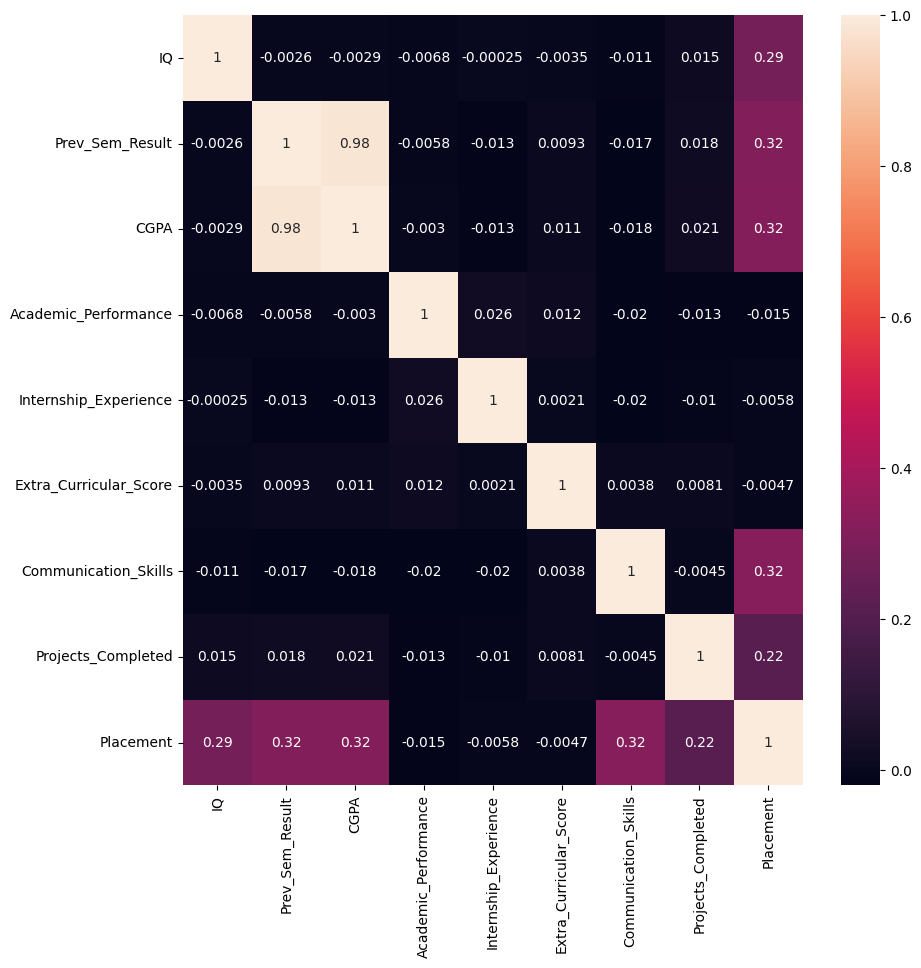

In [15]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)



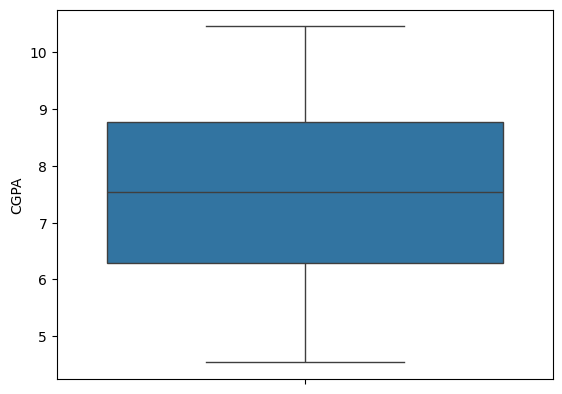

In [16]:
sns.boxplot(df['CGPA'])
plt.show()

In [17]:
df['Placement'].value_counts()

,count
Placement,
0,8341
1,1659


In [18]:
Q1=df['CGPA'].quantile(0.25)
Q3=df['CGPA'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
df=df[(df['CGPA']>lower_limit)&(df['CGPA']<upper_limit)]
#print(outliers)

** Splitting and Feature scaling **

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
X=df.drop('Placement',axis=1)
y=df['Placement']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
scaler=StandardScaler()
# Fit + Transform only on training data
X_train_scaled=scaler.fit_transform(X_train)
# Transform only on testing data
X_test_scaled=scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [23]:
y_pred=model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9035
[[1609   65]
 [ 128  198]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



In [25]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [26]:
y_pred=model.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[1674    0]
 [   0  326]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [28]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train_scaled,y_train)

RandomForestClassifier()

In [29]:
y_pred=model.predict(X_test_scaled)

In [30]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[1674    0]
 [   0  326]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1674
           1       1.00      1.00      1.00       326

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [32]:
# Checking the output
manual_input = pd.DataFrame([{
    'IQ': 120,
    'Prev_Sem_Result': 6.5,
    'CGPA': 8,
    'Academic_Performance': 7.5,
    'Internship_Experience': 1,
    'Extra_Curricular_Score': 5,
    'Communication_Skills': 6.5,
    'Projects_Completed': 2
}])

# Ensure column order matches training data
manual_input = manual_input[X.columns]
manual_input_scaled = scaler.transform(manual_input)
prediction = model.predict(manual_input_scaled)
probability = model.predict_proba(manual_input_scaled)

print("Prediction:", prediction)
print("Placement Probability:", probability[:, 1])

Prediction: [0]
Placement Probability: [0.14]
